# Gray-Scott temporal JEPA — results

Figures summarizing a training run and the **JEPA-vs-surrogate** rollout
comparison that answers The Well's open question: *does latent prediction give
more stable long-horizon rollouts than the FNO / U-Net field-space surrogates?*

Inputs (all artifact-guarded — missing files just show a note):

| Source | File | Figure |
|--------|------|--------|
| `ExperimentLogger` | `losses_step.csv` | training loss curves (total / vc / pred) |
| `ExperimentLogger` | `losses_epoch.csv` | train vs val loss |
| `ExperimentLogger` | `predictions/latent_metrics.json` | latent MSE vs horizon per epoch |
| `ExperimentLogger` | `predictions/field_metrics.json` | field MSE vs horizon (optional) |
| `ExperimentLogger` | `predictions/latent_epoch{E}.png` | embedded latent panel |
| baselines | `per_model_rollout_vrmse.csv` | **VRMSE vs horizon** (JEPA vs FNO / U-Net / persistence) |
| baselines | `metrics.csv` | window VRMSE bar chart (one-step / 6:12 / 13:30) |
| baselines | `rollout_comparison.png` | embedded rollout filmstrip |

Set `RUN_DIR` / `BASELINE_DIR` below. If left empty, the notebook writes a small
set of **synthetic demo artifacts** (same on-disk layout) so every figure renders.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import plot_style as ps

ps.setup_style()

# --- configuration -------------------------------------------------------- #
# An ExperimentLogger run folder (contains losses_*.csv, predictions/).
RUN_DIR = ""           # e.g. ".../checkpoints/gray_scott/dev/run_2026-..._.."
# A baselines output folder (per_model_rollout_vrmse.csv, metrics.csv, ...).
BASELINE_DIR = ""      # e.g. ".../outputs/baselines/gray_scott_reaction_diffusion"
# Optional CSV with columns (horizon, vrmse) for the JEPA decoded rollout, to
# overlay on the headline figure once eval.py build_decoder/vrmse are implemented.
JEPA_ROLLOUT_CSV = ""

USE_DEMO_IF_MISSING = True   # write synthetic artifacts when paths are empty/absent

run_dir = Path(RUN_DIR) if RUN_DIR else None
baseline_dir = Path(BASELINE_DIR) if BASELINE_DIR else None
jepa_csv = Path(JEPA_ROLLOUT_CSV) if JEPA_ROLLOUT_CSV else None

_have_run = run_dir is not None and run_dir.exists()
_have_base = baseline_dir is not None and baseline_dir.exists()
if USE_DEMO_IF_MISSING and not (_have_run and _have_base):
    demo_run, demo_base, demo_jepa = ps.make_demo_results(ps.OUT_DIR / "demo_artifacts")
    if not _have_run:
        run_dir = demo_run
    if not _have_base:
        baseline_dir = demo_base
        jepa_csv = jepa_csv or demo_jepa
    print("[demo] using synthetic artifacts (set RUN_DIR / BASELINE_DIR for real runs)")

print("RUN_DIR     :", run_dir)
print("BASELINE_DIR:", baseline_dir)
print("JEPA_ROLLOUT_CSV:", jepa_csv)


def note(msg):
    """Render a small placeholder for a missing artifact."""
    fig, ax = plt.subplots(figsize=(7, 1.2))
    ax.axis("off")
    ax.text(0.5, 0.5, msg, ha="center", va="center", fontsize=12, color="#a33")
    plt.show()

[demo] using synthetic artifacts (set RUN_DIR / BASELINE_DIR for real runs)
RUN_DIR     : /home/sardi/eb_jepa_bellwethers/figures/out/demo_artifacts/run_demo
BASELINE_DIR: /home/sardi/eb_jepa_bellwethers/figures/out/demo_artifacts/baselines_demo
JEPA_ROLLOUT_CSV: /home/sardi/eb_jepa_bellwethers/figures/out/demo_artifacts/baselines_demo/jepa_rollout_vrmse.csv


## 1. Training loss curves

Per-step `total_loss`, `vc_loss` (anti-collapse) and `pred_loss` (latent
prediction) from `losses_step.csv`, raw + smoothed.

In [2]:
step_csv = run_dir / "losses_step.csv" if run_dir else None
if step_csv and step_csv.exists():
    df = pd.read_csv(step_csv)

    def smooth(y, w=21):
        return pd.Series(y).rolling(w, center=True, min_periods=1).mean().to_numpy()

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    palette = {"total_loss": "#222", "pred_loss": "#2a788e", "vc_loss": "#b5367a"}
    for col, color in palette.items():
        if col in df:
            ax.plot(df["step"], df[col], color=color, alpha=0.2, lw=1)
            ax.plot(df["step"], smooth(df[col].to_numpy()), color=color, lw=2.4, label=col)
    ax.set_xlabel("training step")
    ax.set_ylabel("loss")
    ax.set_title("Training losses")
    ax.legend()
    fig.tight_layout()
    ps.savefig(fig, "01_loss_curves")
    plt.show()
else:
    note(f"no losses_step.csv (looked in {step_csv})")

/tmp/ipykernel_21980/840773903.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 2. Train vs validation loss

Per-epoch generalization gap from `losses_epoch.csv`.

In [3]:
epoch_csv = run_dir / "losses_epoch.csv" if run_dir else None
if epoch_csv and epoch_csv.exists():
    df = pd.read_csv(epoch_csv)
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    if "train_loss" in df:
        ax.plot(df["epoch"], df["train_loss"], marker="o", ms=4, label="train")
    if "val_loss" in df:
        ax.plot(df["epoch"], df["val_loss"], marker="s", ms=4, label="val")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title("Train vs validation loss")
    ax.legend()
    fig.tight_layout()
    ps.savefig(fig, "02_train_val_loss")
    plt.show()
else:
    note(f"no losses_epoch.csv (looked in {epoch_csv})")

/tmp/ipykernel_21980/2597863615.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 3. Latent prediction quality vs horizon

From `predictions/latent_metrics.json`: per-horizon latent MSE (`z_hat` vs the EMA
target `z`), one curve per logged epoch. The curves should drop as training
progresses — the predictor learns to roll latents forward.

In [4]:
latent_json = run_dir / "predictions" / "latent_metrics.json" if run_dir else None
if latent_json and latent_json.exists():
    data = json.loads(latent_json.read_text())
    epochs = sorted(data.keys(), key=int)
    cmap = plt.colormaps["viridis"]
    fig, ax = plt.subplots(figsize=(7.8, 4.8))
    for i, e in enumerate(epochs):
        rec = data[e]
        color = cmap(i / max(1, len(epochs) - 1))
        ax.plot(rec["horizon"], rec["latent_mse"], marker="o", ms=4,
                color=color, label=f"epoch {e}")
    ax.set_xlabel("rollout horizon (steps)")
    ax.set_ylabel("latent MSE")
    ax.set_title("Latent prediction error vs horizon")
    ax.legend(title="training", ncol=2)
    fig.tight_layout()
    ps.savefig(fig, "03_latent_mse_horizon")
    plt.show()
else:
    note(f"no latent_metrics.json (looked in {latent_json})")

/tmp/ipykernel_21980/3416925950.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 4. Field prediction error vs horizon (optional)

If a latent→field decoder was supplied during training, `field_metrics.json`
records per-horizon field-space MSE.

In [5]:
field_json = run_dir / "predictions" / "field_metrics.json" if run_dir else None
if field_json and field_json.exists():
    data = json.loads(field_json.read_text())
    epochs = sorted(data.keys(), key=int)
    cmap = plt.colormaps["magma"]
    fig, ax = plt.subplots(figsize=(7.8, 4.8))
    for i, e in enumerate(epochs):
        rec = data[e]
        color = cmap(0.2 + 0.6 * i / max(1, len(epochs) - 1))
        ax.plot(rec["horizon"], rec["field_mse"], marker="o", ms=4,
                color=color, label=f"epoch {e}")
    ax.set_xlabel("rollout horizon (steps)")
    ax.set_ylabel("field MSE")
    ax.set_title("Decoded field prediction error vs horizon")
    ax.legend(title="training")
    fig.tight_layout()
    ps.savefig(fig, "04_field_mse_horizon")
    plt.show()
else:
    note("no field_metrics.json (decoder was not supplied during training — optional)")

/tmp/ipykernel_21980/4005384045.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 5. Latent prediction panel

The latest `predictions/latent_epoch{E}.png` written during training (rows:
target `z` / prediction `z_hat` / `|error|`; columns: increasing horizon).

showing latent_epoch19.png


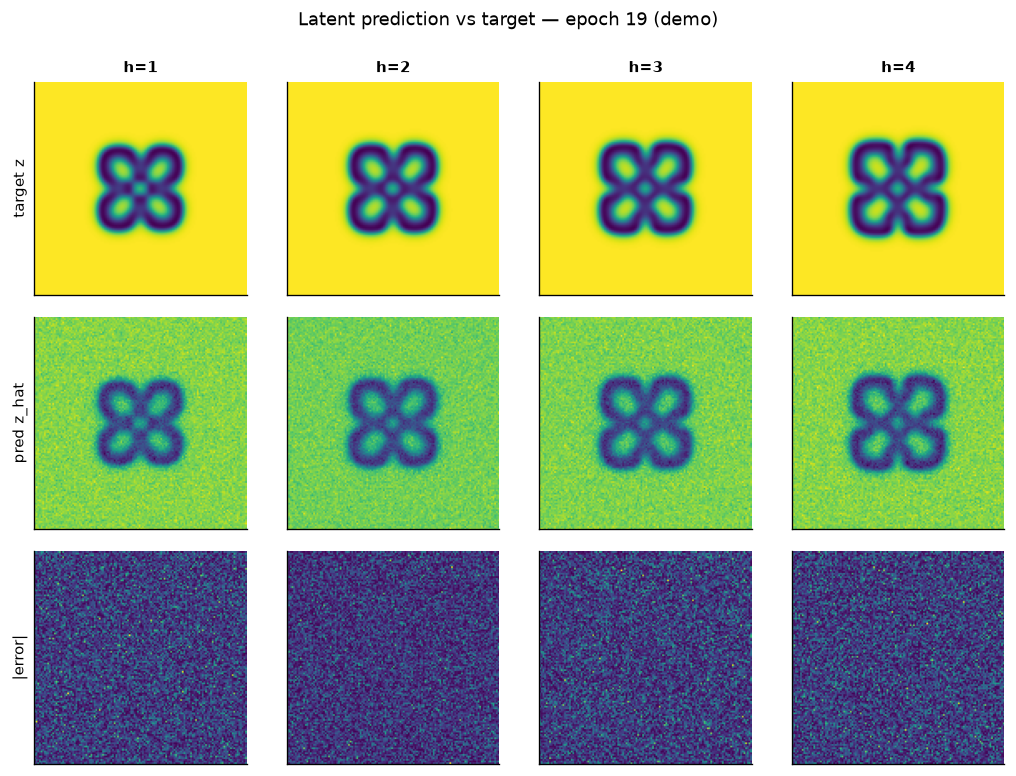

In [6]:
from IPython.display import Image as IPyImage, display

panels = sorted((run_dir / "predictions").glob("latent_epoch*.png")) if run_dir else []
if panels:
    latest = max(panels, key=lambda p: int("".join(filter(str.isdigit, p.stem)) or 0))
    print("showing", latest.name)
    display(IPyImage(filename=str(latest)))
else:
    note("no latent_epoch*.png panel found")

## 6. Headline — VRMSE vs horizon: JEPA vs surrogates

The answer to The Well's question. Field-space VRMSE of the autoregressive
rollout, per horizon, for each surrogate (`FNO`, `UNetClassic`), the
`persistence` and `mean` references, and the **JEPA decoded rollout** overlaid
when a `JEPA_ROLLOUT_CSV` is available. Lower-and-flatter than the surrogates
means latent prediction is more stable at long horizons.

In [7]:
roll_csv = baseline_dir / "per_model_rollout_vrmse.csv" if baseline_dir else None
if roll_csv and roll_csv.exists():
    df = pd.read_csv(roll_csv)
    horizons = df["horizon"].to_numpy()
    fig, ax = plt.subplots(figsize=(8.2, 5.0))
    style = {"persistence": dict(color="k", ls="--", lw=1.6),
             "mean": dict(color="gray", ls=":", lw=1.4)}
    for col in df.columns:
        if col == "horizon":
            continue
        kw = style.get(col, dict(marker="o", ms=3))
        ax.plot(horizons, df[col], label=col, **kw)
    # Overlay the JEPA decoded rollout if available.
    if jepa_csv and Path(jepa_csv).exists():
        jdf = pd.read_csv(jepa_csv)
        ax.plot(jdf["horizon"], jdf["vrmse"], color="#d1495b", lw=3.0,
                marker="D", ms=4, label="JEPA (latent→field)")
    ax.axhline(1.0, color="#999", ls=":", lw=1)
    ax.set_yscale("log")
    ax.set_xlabel("rollout horizon (steps)")
    ax.set_ylabel("VRMSE (field-averaged, physical space)")
    ax.set_title("Autoregressive rollout VRMSE: JEPA vs surrogates")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(ncol=2)
    fig.tight_layout()
    ps.savefig(fig, "06_vrmse_vs_horizon")
    plt.show()
else:
    note(f"no per_model_rollout_vrmse.csv (looked in {roll_csv})")

/tmp/ipykernel_21980/3082589661.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Window summary

The Well reports aggregated VRMSE over horizon windows. This bar chart compares
one-step, `6:12` and `13:30` window VRMSE from `metrics.csv`.

In [8]:
metrics_csv = baseline_dir / "metrics.csv" if baseline_dir else None
if metrics_csv and metrics_csv.exists():
    df = pd.read_csv(metrics_csv)
    windows = [c for c in ("one_step_vrmse", "rollout_6:12", "rollout_13:30") if c in df.columns]
    models = df["model"].tolist()
    x = np.arange(len(windows))
    width = 0.8 / max(1, len(models))
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    for i, m in enumerate(models):
        vals = [pd.to_numeric(df.loc[df.model == m, w], errors="coerce").iloc[0] for w in windows]
        ax.bar(x + i * width, vals, width, label=m)
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(windows, rotation=0)
    ax.set_ylabel("VRMSE")
    ax.set_title("Window VRMSE by model")
    ax.legend(ncol=2)
    fig.tight_layout()
    ps.savefig(fig, "07_window_summary")
    plt.show()
else:
    note(f"no metrics.csv (looked in {metrics_csv})")

/tmp/ipykernel_21980/2688140924.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 8. Rollout filmstrip

The baseline evaluator's `rollout_comparison.png` (ground truth vs each model at
several horizons), embedded directly when present.

In [9]:
filmstrip = baseline_dir / "rollout_comparison.png" if baseline_dir else None
if filmstrip and filmstrip.exists():
    display(IPyImage(filename=str(filmstrip)))
else:
    note("no rollout_comparison.png — run the baseline evaluator with --viz to produce it")

/tmp/ipykernel_21980/1427898819.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
